# Statistical Arbitrage in Cryptocurrency Markets
## A Quantitative Finance Research Project

**Course:** Quantitative Finance | **Date:** May 2026

---

## Research Questions

> Do momentum and mean-reversion effects exist in crypto markets, and can
> they be combined into a profitable, cost-aware trading strategy?

### Hypotheses

| # | Hypothesis | Mechanism |
|---|-----------|-----------|
| H1 | **Momentum** (7–90 day) produces positive risk-adjusted returns | Slow diffusion of information; trend-following retail flows |
| H2 | **Short-term reversal** (1–3 day) produces positive returns | Overreaction by retail; liquidity shocks that quickly revert |
| H3 | **Volume-weighted signals** outperform equal-weighted equivalents | High-volume moves carry more information |
| H4 | A **combined portfolio** (momentum + reversal) improves Sharpe | Low correlation between signal families provides diversification |

### Strategy Design

- **Universe**: Top 25 cryptocurrencies by market cap (Binance, public API)
- **Data**: 3+ years daily / 18 months hourly OHLCV from Binance
- **Signal**: Cross-sectional z-score; **long top quintile, short bottom quintile**
- **Rebalancing**: Daily at market close
- **Cost model**: 20 bps (market orders) or 7 bps (limit orders) per one-way trade
- **Benchmark**: BTC/USDT total return


In [1]:
# ── Uncomment the line below on first run ─────────────────────────────────────
# !pip install -r requirements.txt -q

import sys, os, warnings
sys.path.insert(0, os.path.join(os.getcwd(), "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from datetime import datetime

# Project modules
import config
from data_pipeline import (
    fetch_and_store_universe, load_ohlcv_wide, load_all_fields, load_returns
)
from signals.momentum import all_momentum_signals
from signals.reversal  import all_reversal_signals
from backtester        import run_all_backtests
from evaluator         import (
    compare_strategies, full_tearsheet,
    annualized_return, annualized_vol, sharpe_ratio, max_drawdown,
    drawdown_series, rolling_sharpe
)
from portfolio import build_combinations
import plotting as pl

#plt.style.use("seaborn-whitegrid")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 20)

print(f"NumPy  {np.__version__}  |  Pandas {pd.__version__}  |  Python {sys.version.split()[0]}")
print("✓ All imports successful")


NumPy  2.2.6  |  Pandas 2.2.2  |  Python 3.12.10
✓ All imports successful


---
## Section 1 — Data Collection

We fetch Open / High / Low / Close / Volume (OHLCV) data for **25 cryptocurrencies**
from **Binance** via the [CCXT](https://github.com/ccxt/ccxt) library.

- No API key required — all requests hit public REST endpoints
- Data is cached locally as **Parquet files** (columnar, fast I/O)
- On first run, fetching ~25 coins × 3 years of daily data takes ≈ 2–3 minutes
- Subsequent runs load from the cache (instant)

### Universe Selection

Top 25 by market capitalisation (as of early 2025):

| Tier | Symbols |
|------|---------|
| Mega-cap | BTC, ETH, BNB |
| Large-cap | SOL, XRP, DOGE, ADA, AVAX |
| Mid-cap | LINK, DOT, MATIC, LTC, BCH, UNI, ATOM |
| Small-cap | XLM, ETC, ALGO, FIL, TRX, NEAR, APT, OP, ARB, VET |


In [2]:
# ─── Fetch daily OHLCV (2021-01-01 to now) ───────────────────────────────────
# Set force_refresh=True to re-download even if local cache exists
print("Fetching daily data ...")
daily_results = fetch_and_store_universe(timeframe="1d", force_refresh=False)

# ─── Fetch hourly OHLCV (2023-11-01 to now) ──────────────────────────────────
print("\nFetching hourly data ...")
hourly_results = fetch_and_store_universe(timeframe="1h", force_refresh=False)

ok_daily  = [s for s, v in daily_results.items() if v]
ok_hourly = [s for s, v in hourly_results.items() if v]
print(f"\nDaily  data: {len(ok_daily)} symbols")
print(f"Hourly data: {len(ok_hourly)} symbols")


Fetching daily data ...


Fetching 1d: 100%|██████████| 25/25 [00:05<00:00,  4.24it/s]



OK 1d: 25/25 symbols fetched successfully

Fetching hourly data ...


Fetching 1h: 100%|██████████| 25/25 [00:16<00:00,  1.50it/s]


OK 1h: 25/25 symbols fetched successfully

Daily  data: 25 symbols
Hourly data: 25 symbols


In [4]:
# ─── Load price and volume data ───────────────────────────────────────────────
fields_d = load_all_fields("1d")      # dict: {field: wide DataFrame}
close_d  = fields_d["close"]
volume_d = fields_d["volume"]

# Use coins present in BOTH close and volume with enough history
min_days = 200
valid_cols = close_d.columns[close_d.notna().sum() >= min_days]
close_d  = close_d[valid_cols]
volume_d = volume_d[valid_cols]

print(f"Universe (daily):  {len(close_d.columns)} symbols, "
      f"{len(close_d)} trading days")
print(f"Date range:        {close_d.index.min().date()} → {close_d.index.max().date()}")
print(f"\nMissing values (%):")
miss_pct = (close_d.isna().sum() / len(close_d) * 100).sort_values(ascending=False)
print(miss_pct[miss_pct > 0].round(1).to_string() or "  None — perfect data coverage")

# ─── Build returns ────────────────────────────────────────────────────────────
# Log returns for signals; simple returns for P&L
log_ret_d    = np.log(close_d / close_d.shift(1))
simple_ret_d = close_d.pct_change()

btc_prices = close_d["BTC/USDT"] if "BTC/USDT" in close_d.columns else close_d.iloc[:, 0]
btc_ret    = btc_prices.pct_change()

print(f"\nBTC annualized return (full sample): "
      f"{annualized_return(btc_ret.dropna())*100:.1f}%")
print(f"BTC annualized volatility:           "
      f"{annualized_vol(btc_ret.dropna())*100:.1f}%")
print(f"BTC Sharpe ratio (rf=0):             "
      f"{sharpe_ratio(btc_ret.dropna()):.2f}")


Universe (daily):  25 symbols, 1949 trading days
Date range:        2021-01-01 → 2026-05-03

Missing values (%):
ARB/USDT     41.600
APT/USDT     33.700
MATIC/USDT   30.800
OP/USDT      26.500

BTC annualized return (full sample): 20.2%
BTC annualized volatility:           58.3%
BTC Sharpe ratio (rf=0):             0.35


---
## Section 2 — Exploratory Data Analysis

Before testing strategies, we characterise the data:

1. **Return distributions**: Are crypto returns fat-tailed? (They are — kurtosis >> 3)
2. **Serial correlation (autocorrelation)**: Any evidence of momentum / reversal in raw returns?
3. **Cross-asset correlation**: How correlated are coins? (High correlation = harder to diversify)

### Why This Matters for Strategy Design

- **Fat tails** → signal noise is higher; winsorisation and z-scoring are essential
- **Positive autocorrelation at lag 1–5** → suggests momentum is exploitable
- **Negative autocorrelation at lag 1** → suggests 1-day reversal is exploitable
- **High cross-correlation** → cross-sectional momentum/reversal more useful than time-series alone


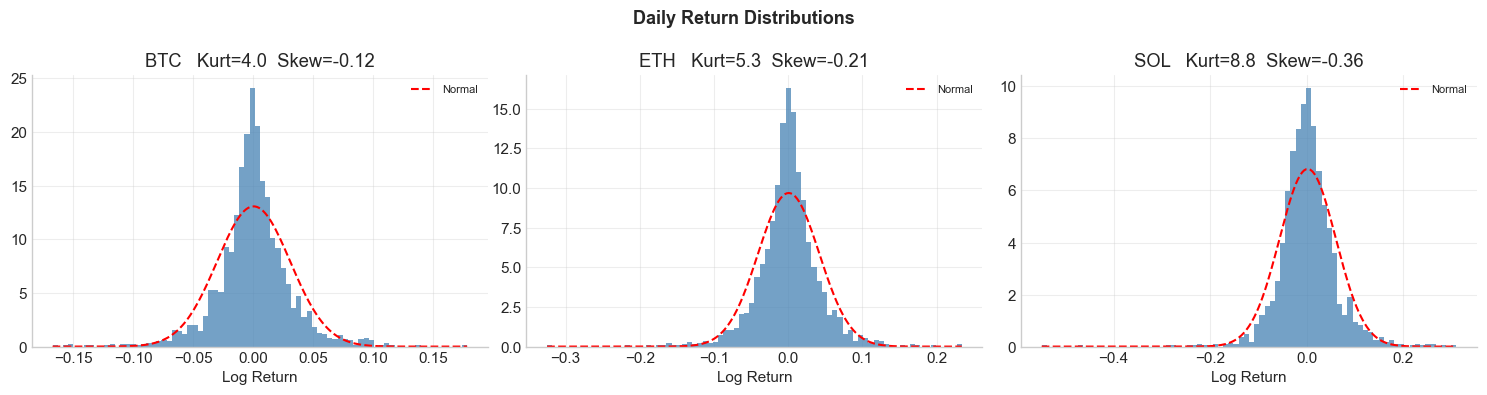


Note: Kurtosis >> 3 confirms fat tails — normal distribution underestimates tail risk.


In [5]:
# ─── 1. Return distribution for selected coins ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Daily Return Distributions", fontsize=13, fontweight="bold")

coins_to_plot = ["BTC/USDT", "ETH/USDT", "SOL/USDT"]
coins_to_plot = [c for c in coins_to_plot if c in log_ret_d.columns]

for ax, coin in zip(axes, coins_to_plot):
    r = log_ret_d[coin].dropna()
    r.hist(bins=80, ax=ax, color="steelblue", alpha=0.75, density=True)
    # Normal overlay
    mu, sigma = r.mean(), r.std()
    x = np.linspace(r.min(), r.max(), 200)
    ax.plot(x, 1/(sigma*np.sqrt(2*np.pi)) * np.exp(-0.5*((x-mu)/sigma)**2),
            "r--", lw=1.5, label="Normal")
    ax.set_title(f"{coin.replace('/USDT', '')}   "
                 f"Kurt={r.kurt():.1f}  Skew={r.skew():.2f}")
    ax.set_xlabel("Log Return")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print("\nNote: Kurtosis >> 3 confirms fat tails — normal distribution underestimates tail risk.")


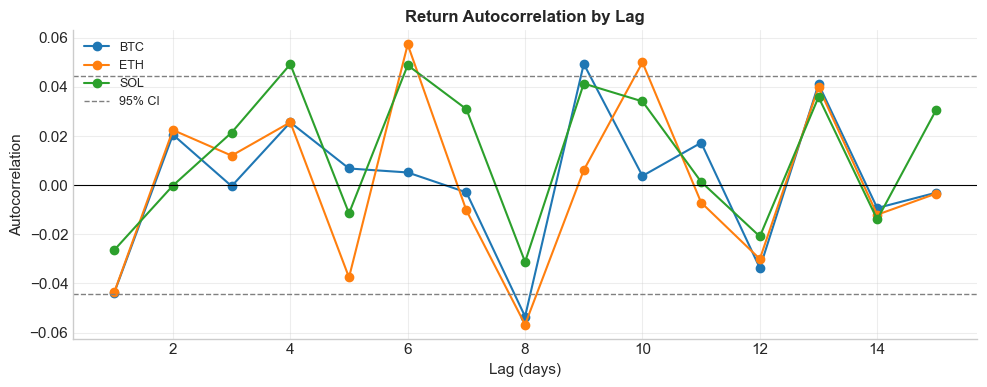


Key observations:
  • Lag-1 autocorrelation is often slightly negative → 1-day reversal signal
  • Lags 5–15 may show mild positive autocorrelation → weekly momentum


In [6]:
# ─── 2. Return autocorrelation (momentum vs reversal evidence) ───────────────
lags = range(1, 16)
fig, ax = plt.subplots(figsize=(10, 4))

for coin in ["BTC/USDT", "ETH/USDT", "SOL/USDT"]:
    if coin not in log_ret_d.columns:
        continue
    r = log_ret_d[coin].dropna()
    acf = [r.autocorr(lag=l) for l in lags]
    ax.plot(list(lags), acf, "o-", label=coin.replace("/USDT", ""), lw=1.5)

ax.axhline(0, color="black", lw=0.8)
ax.axhline( 1.96 / np.sqrt(len(log_ret_d)), color="grey", ls="--", lw=1, label="95% CI")
ax.axhline(-1.96 / np.sqrt(len(log_ret_d)), color="grey", ls="--", lw=1)
ax.set_xlabel("Lag (days)")
ax.set_ylabel("Autocorrelation")
ax.set_title("Return Autocorrelation by Lag", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("  • Lag-1 autocorrelation is often slightly negative → 1-day reversal signal")
print("  • Lags 5–15 may show mild positive autocorrelation → weekly momentum")


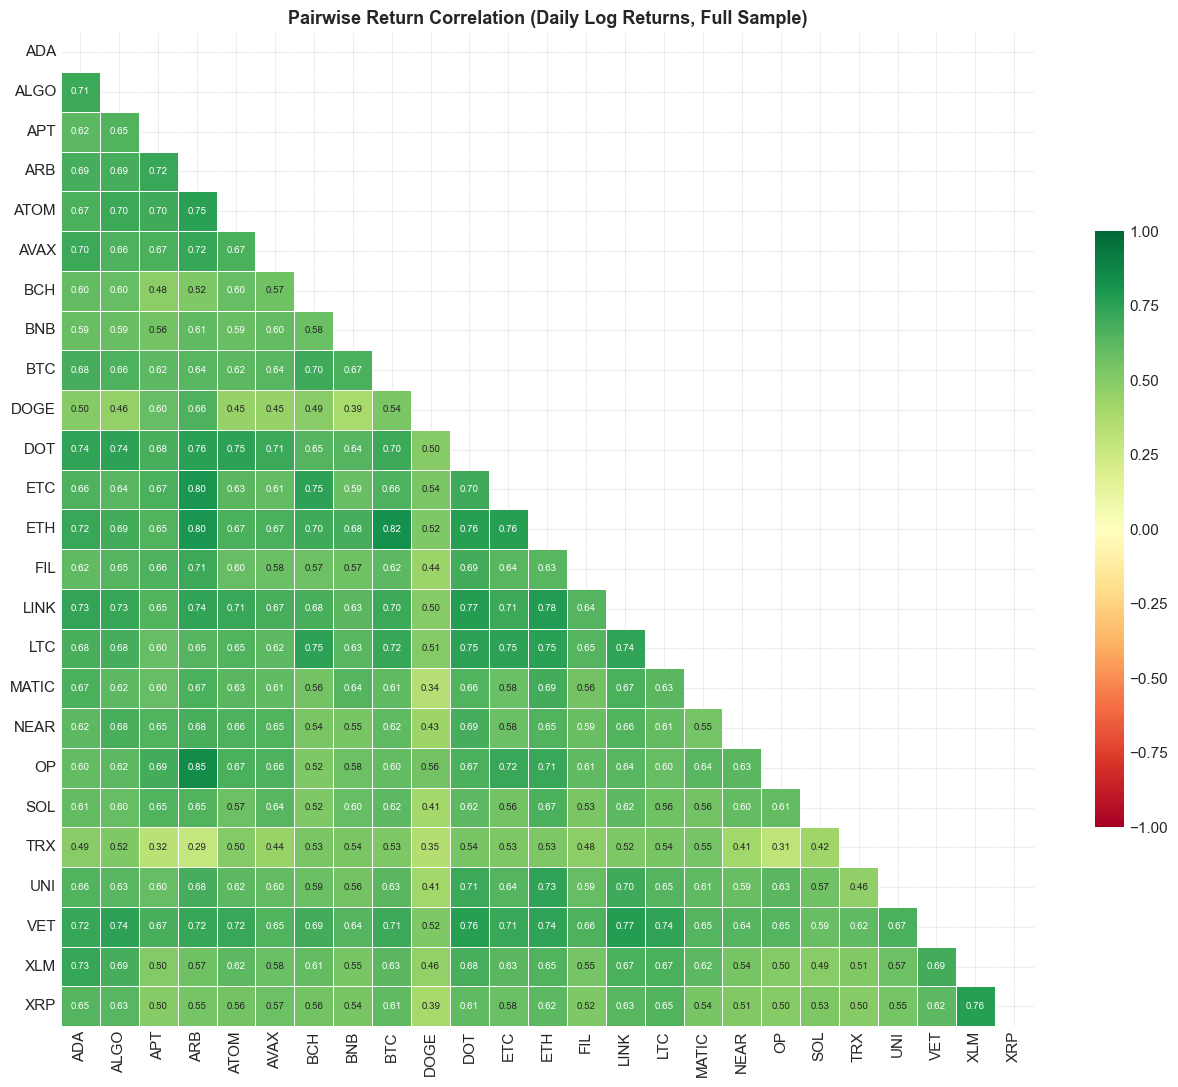


Average pairwise correlation: 0.62
High cross-correlation means the market has one dominant factor (BTC).
Cross-sectional strategies (ranking coins vs each other) are market-neutral by construction.


In [7]:
# ─── 3. Cross-asset correlation heatmap ─────────────────────────────────────
pl.plot_correlation_heatmap(
    log_ret_d.dropna(how="all"),
    title="Pairwise Return Correlation (Daily Log Returns, Full Sample)",
    figsize=(13, 11)
)
plt.show()

avg_corr = log_ret_d.corr().values
np.fill_diagonal(avg_corr, np.nan)
print(f"\nAverage pairwise correlation: {np.nanmean(avg_corr):.2f}")
print("High cross-correlation means the market has one dominant factor (BTC).")
print("Cross-sectional strategies (ranking coins vs each other) are market-neutral by construction.")


---
## Section 3 — Momentum Signals

### Economic Rationale

**Momentum** (Jegadeesh & Titman, 1993) is one of the most replicated factors in finance:
assets that outperformed over the past 3–12 months tend to continue outperforming.

In crypto, the effect is driven by:
- **Slow information diffusion** to retail participants
- **Herding behaviour** and trend-following algorithms
- **Attention effects**: popular coins attract more buyers after price rises

### Signals Tested

| Signal | Description | Lookback Windows |
|--------|-------------|-----------------|
| `mom_Nd` | Time-series momentum (log price change) | 1, 3, 7, 14, 30, 60, 90 days |
| `cs_mom_Nd` | Cross-sectional rank momentum | 7, 30, 90 days |
| `vw_mom_Nd` | Volume-weighted momentum | 7, 14, 30 days |
| `weekday_mom` | Weekday seasonality (Mon–Fri vs Sat–Sun) | Expanding window |

### Look-Ahead Bias Prevention

All signals are computed so that **signal[t]** uses only data observed at or before
the close of day **t**. Weights derived from signal[t] earn the return from day t to t+1.


Building momentum signals...
  Generated 14 momentum signals:
    mom_1d               shape=(1948, 25)  non-null rows=1948
    mom_3d               shape=(1948, 25)  non-null rows=1948
    mom_7d               shape=(1946, 25)  non-null rows=1946
    mom_14d              shape=(1942, 25)  non-null rows=1942
    mom_30d              shape=(1934, 25)  non-null rows=1934
    mom_60d              shape=(1919, 25)  non-null rows=1919
    mom_90d              shape=(1904, 25)  non-null rows=1904
    cs_mom_7d            shape=(1946, 25)  non-null rows=1946
    cs_mom_30d           shape=(1934, 25)  non-null rows=1934
    cs_mom_90d           shape=(1904, 25)  non-null rows=1904
    vw_mom_7d            shape=(1945, 25)  non-null rows=1945
    vw_mom_14d           shape=(1937, 25)  non-null rows=1937
    vw_mom_30d           shape=(1921, 25)  non-null rows=1921
    weekday_mom          shape=(1899, 25)  non-null rows=1899

Plotting 30-day momentum signal heatmap (last 60 days)...


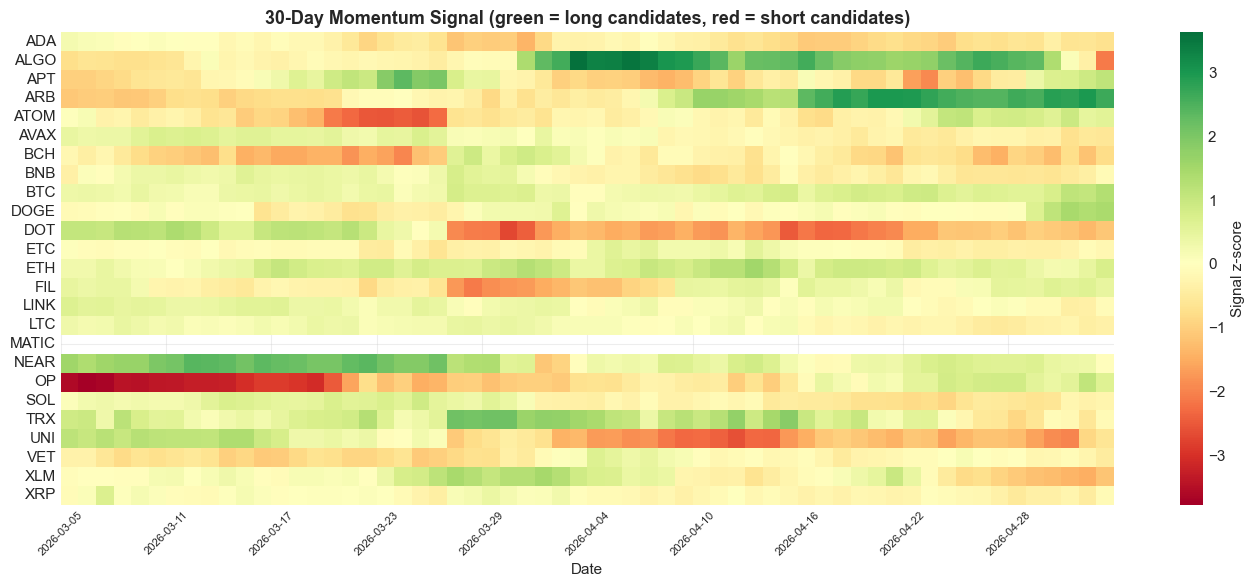

In [8]:
# ─── Build all momentum signals ──────────────────────────────────────────────
print("Building momentum signals...")
mom_signals = all_momentum_signals(close_d, volume_d)
print(f"  Generated {len(mom_signals)} momentum signals:")
for name in mom_signals:
    sig = mom_signals[name].dropna(how="all")
    print(f"    {name:<20} shape={sig.shape}  non-null rows={sig.notna().any(axis=1).sum()}")

# ─── Visualise the 30-day momentum signal ────────────────────────────────────
print("\nPlotting 30-day momentum signal heatmap (last 60 days)...")
pl.plot_signal_heatmap(
    mom_signals["mom_30d"],
    title="30-Day Momentum Signal (green = long candidates, red = short candidates)",
    last_n_days=60
)
plt.show()


In [9]:
# ─── Backtest all momentum signals ───────────────────────────────────────────
print("Running momentum backtests (market order costs, 20 bps) ...")
mom_results = run_all_backtests(mom_signals, close_d, cost_mode="market")

# ─── Performance table ────────────────────────────────────────────────────────
mom_table = compare_strategies(mom_results, btc_prices)

display_cols = [
    "Ann. Return (net) %", "Ann. Volatility %", "Sharpe Ratio",
    "Max Drawdown %", "Alpha (ann) %", "Beta vs BTC", "Win Rate %", "Avg Daily Turnover"
]
print("\n" + "="*70)
print("MOMENTUM STRATEGY PERFORMANCE SUMMARY")
print("="*70)
print(mom_table[display_cols].round(2).to_string())

# Quick comparison: gross vs net Sharpe to see cost impact
print("\nSharpe gross vs net (cost drag):")
for name, res in mom_results.items():
    r = res["returns"]
    sr_gross = sharpe_ratio(r["gross_return"].dropna())
    sr_net   = sharpe_ratio(r["net_return"].dropna())
    print(f"  {name:<22}  gross={sr_gross:+.2f}  net={sr_net:+.2f}  "
          f"drag={sr_gross-sr_net:.2f}")


Running momentum backtests (market order costs, 20 bps) ...
  > mom_1d
  > mom_3d
  > mom_7d
  > mom_14d
  > mom_30d
  > mom_60d
  > mom_90d
  > cs_mom_7d
  > cs_mom_30d
  > cs_mom_90d
  > vw_mom_7d
  > vw_mom_14d
  > vw_mom_30d
  > weekday_mom

MOMENTUM STRATEGY PERFORMANCE SUMMARY
             Ann. Return (net) %  Ann. Volatility %  Sharpe Ratio  Max Drawdown %  Alpha (ann) %  Beta vs BTC  Win Rate %  Avg Daily Turnover
Strategy                                                                                                                                     
mom_14d                   47.970             61.660         0.780         -61.440         83.340       -0.080      49.900               0.450
vw_mom_14d                28.880             57.240         0.500         -58.070         52.960       -0.030      47.540               0.400
cs_mom_30d                30.900             62.090         0.500         -74.810         63.770       -0.090      48.560               0.310
mom_30

---
## Section 4 — Reversal Signals

### Economic Rationale

**Short-horizon reversal** (Jegadeesh, 1990) is the mirror image of momentum:
over very short horizons (1–5 days), large price moves tend to partially reverse.

Causes in crypto:
- **Retail overreaction**: panic selling / FOMO buying overshoots fair value
- **Leverage cascades**: margin calls force liquidations that overshoot, then snap back
- **Low-volume noise**: thin order books amplify moves that carry no information

### Signals Tested

| Signal | Description |
|--------|-------------|
| `rev_1d` | Negative of yesterday's log return |
| `rev_3d` | Negative of 3-day cumulative return |
| `low_vol_rev` | Reversal amplified on below-median-volume days |
| `pairs_rev` | Pairs spread: trade the z-score of correlated coin spreads |
| `macro_rev` | Reversal scaled up during high-BTC-volatility (risk-off) regimes |

### Pairs Spread (Simplified Statistical Arbitrage)

For correlated pairs (BTC–ETH, LINK–DOT, etc.), the **log-price spread**:
$$z_t = \frac{(\ln P_i - \ln P_j) - \mu}{\sigma}$$
is mean-reverting by construction (cointegration assumption).
When $z_t > 0$: coin $i$ is expensive relative to $j$ → short $i$, long $j$.


Building reversal signals (pairs signal takes ~30 s on 25 coins) ...

  Generated 5 reversal signals:
    rev_1d               shape=(1948, 25)
    rev_3d               shape=(1948, 25)
    low_vol_rev          shape=(1653, 25)
    pairs_rev            shape=(1904, 25)
    macro_rev            shape=(1948, 25)


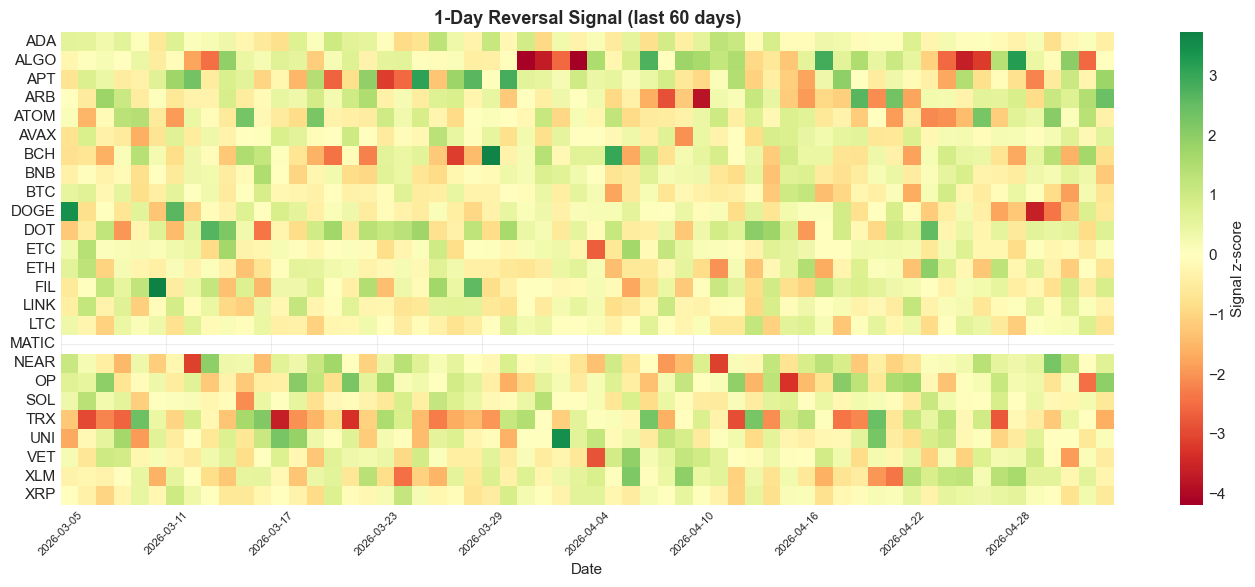

In [10]:
# ─── Build all reversal signals ──────────────────────────────────────────────
btc_col = "BTC/USDT" if "BTC/USDT" in close_d.columns else close_d.columns[0]
print("Building reversal signals (pairs signal takes ~30 s on 25 coins) ...")
rev_signals = all_reversal_signals(close_d, volume_d, btc_col=btc_col)

print(f"\n  Generated {len(rev_signals)} reversal signals:")
for name in rev_signals:
    sig = rev_signals[name].dropna(how="all")
    print(f"    {name:<20} shape={sig.shape}")

# Visualise the 1-day reversal signal
pl.plot_signal_heatmap(
    rev_signals["rev_1d"],
    title="1-Day Reversal Signal (last 60 days)",
    last_n_days=60
)
plt.show()


In [11]:
# ─── Backtest all reversal signals ───────────────────────────────────────────
print("Running reversal backtests ...")
rev_results = run_all_backtests(rev_signals, close_d, cost_mode="market")

rev_table = compare_strategies(rev_results, btc_prices)
print("\n" + "="*70)
print("REVERSAL STRATEGY PERFORMANCE SUMMARY")
print("="*70)
print(rev_table[display_cols].round(2).to_string())


Running reversal backtests ...
  > rev_1d
  > rev_3d
  > low_vol_rev
  > pairs_rev
  > macro_rev

REVERSAL STRATEGY PERFORMANCE SUMMARY
             Ann. Return (net) %  Ann. Volatility %  Sharpe Ratio  Max Drawdown %  Alpha (ann) %  Beta vs BTC  Win Rate %  Avg Daily Turnover
Strategy                                                                                                                                     
low_vol_rev              -60.460             69.220        -0.870         -99.580        -54.390        0.230      38.400               1.060
macro_rev                -75.040             78.270        -0.960         -99.960        -67.890        0.150      47.900               0.920
rev_3d                   -75.040             78.270        -0.960         -99.960        -67.890        0.150      47.900               0.920
rev_1d                   -80.620             74.560        -1.080         -99.990        -75.650        0.110      45.170               1.550
pairs_rev   


ALL STRATEGIES — SORTED BY SHARPE RATIO (NET, AFTER 20 BPS MARKET COSTS)
             Ann. Return (net) %  Ann. Volatility %  Sharpe Ratio  Max Drawdown %  Alpha (ann) %  Beta vs BTC  Win Rate %  Avg Daily Turnover
Strategy                                                                                                                                     
mom_14d                   47.970             61.660         0.780         -61.440         83.340       -0.080      49.900               0.450
vw_mom_14d                28.880             57.240         0.500         -58.070         52.960       -0.030      47.540               0.400
cs_mom_30d                30.900             62.090         0.500         -74.810         63.770       -0.090      48.560               0.310
mom_30d                   30.900             62.090         0.500         -74.810         63.770       -0.090      48.560               0.310
cs_mom_90d                27.550             56.490         0.490         

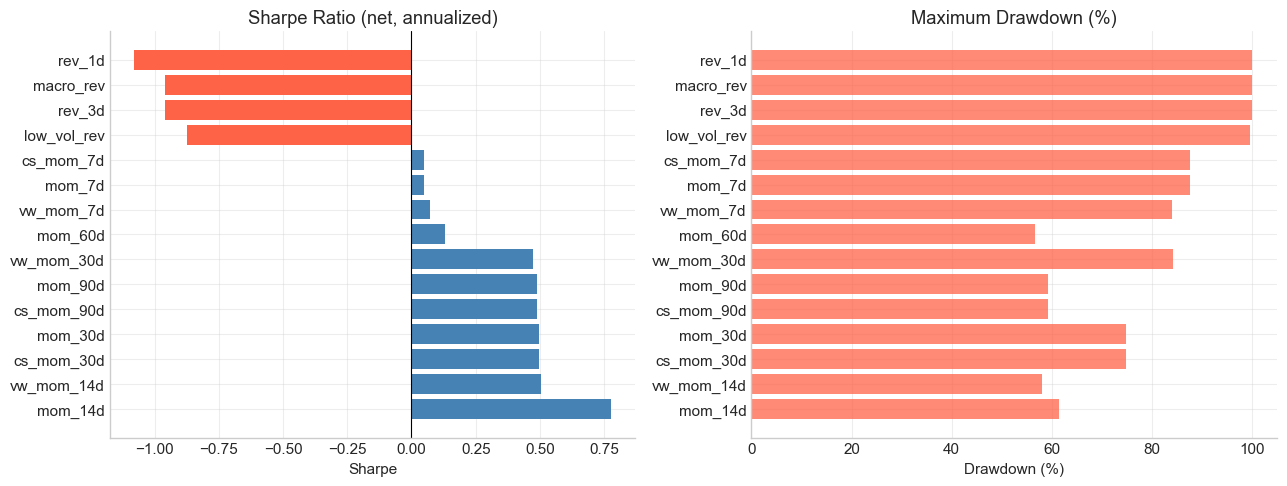


Summary: 11/19 strategies have positive net Sharpe
Best single strategy: mom_14d  (Sharpe = 0.78)


In [12]:
# ─── Combined performance table: all strategies ───────────────────────────────
all_results = {**mom_results, **rev_results}
all_table   = compare_strategies(all_results, btc_prices)

print("\n" + "="*80)
print("ALL STRATEGIES — SORTED BY SHARPE RATIO (NET, AFTER 20 BPS MARKET COSTS)")
print("="*80)
print(all_table[display_cols].round(2).to_string())

# ─── Visual comparison: bar chart ────────────────────────────────────────────
pl.plot_strategy_comparison(all_results, top_n=15, figsize=(13, 5))
plt.show()

# ─── Key statistics ───────────────────────────────────────────────────────────
n_positive = (all_table["Sharpe Ratio"] > 0).sum()
n_total    = len(all_table)
best = all_table["Sharpe Ratio"].idxmax()
print(f"\nSummary: {n_positive}/{n_total} strategies have positive net Sharpe")
print(f"Best single strategy: {best}  (Sharpe = {all_table.loc[best,'Sharpe Ratio']:.2f})")


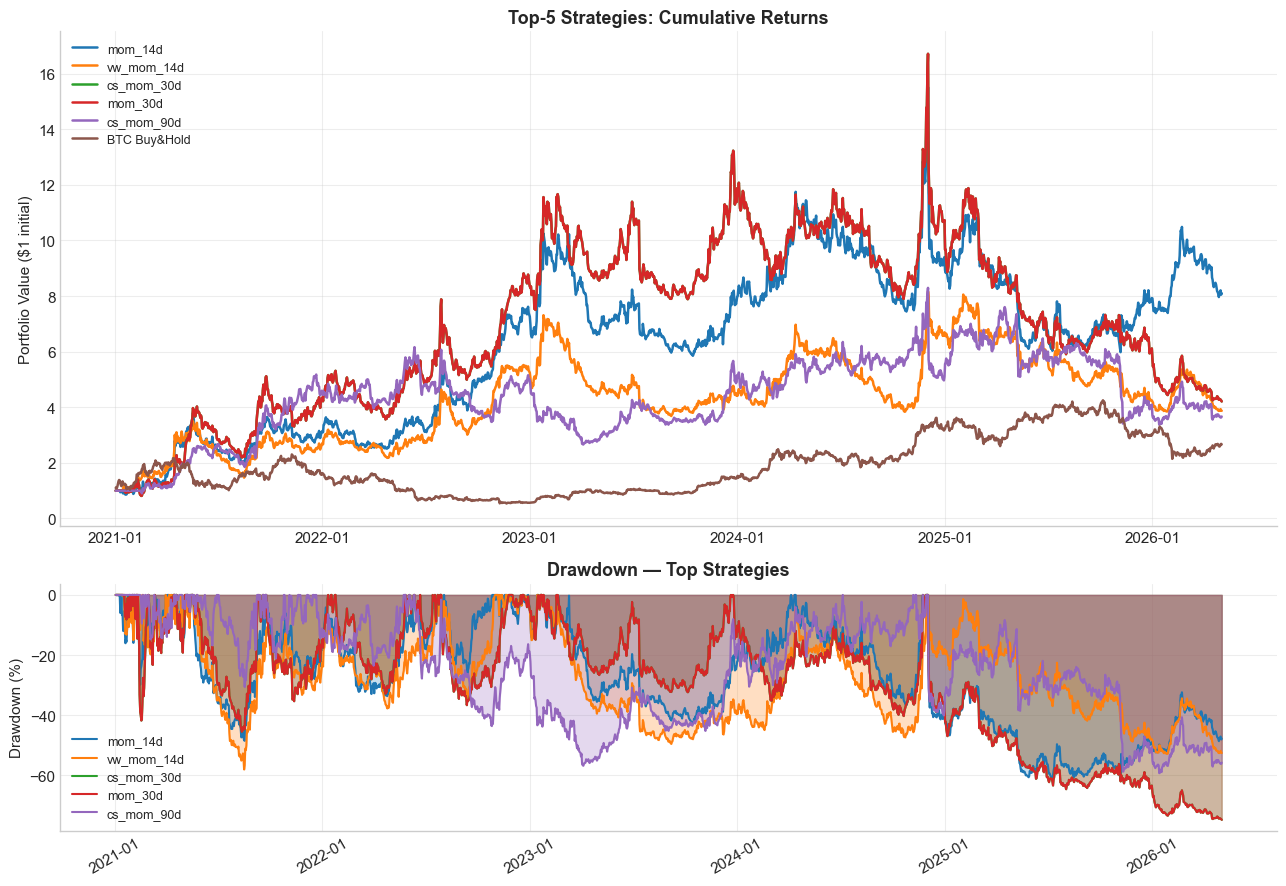

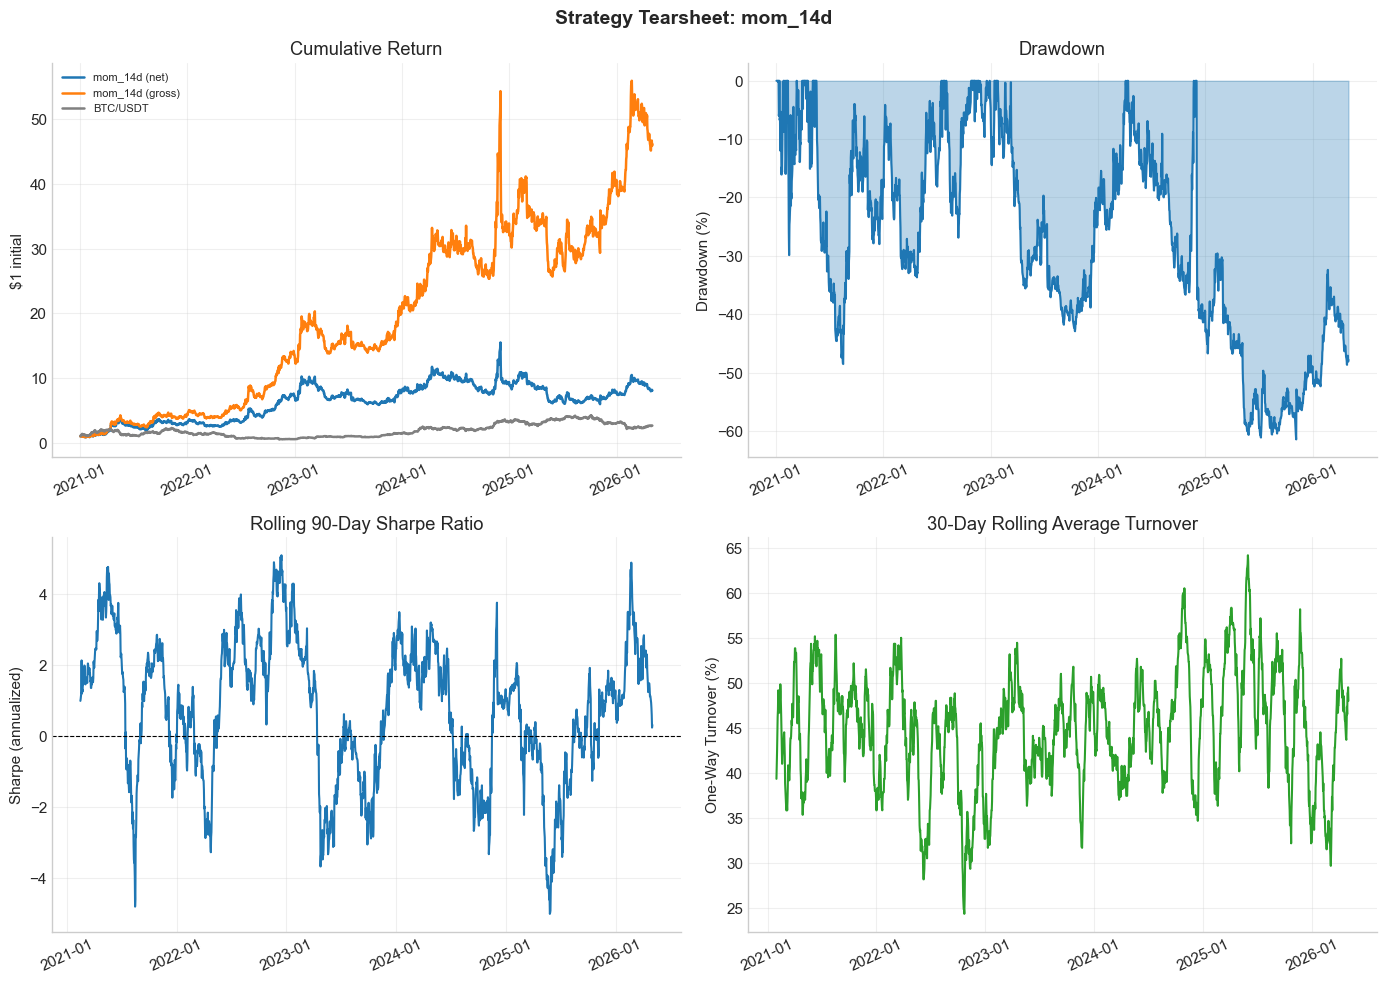

In [13]:
# ─── Equity curves for top-5 strategies ──────────────────────────────────────
top5_names = all_table["Sharpe Ratio"].nlargest(5).index.tolist()
top5_rets  = {
    name: all_results[name]["returns"]["net_return"]
    for name in top5_names
}
top5_rets["BTC Buy&Hold"] = btc_ret  # benchmark

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9),
                                gridspec_kw={"height_ratios": [2, 1]})

pl.plot_cumulative_returns(top5_rets, title="Top-5 Strategies: Cumulative Returns", ax=ax1)
pl.plot_drawdown(
    {k: v for k, v in top5_rets.items() if k != "BTC Buy&Hold"},
    title="Drawdown — Top Strategies",
    ax=ax2
)
plt.tight_layout()
plt.show()

# Print rolling Sharpe for best strategy
best_name = top5_names[0]
fig_best = pl.plot_tearsheet(
    all_results[best_name], btc_ret,
    label=best_name
)
plt.show()


---
## Section 5 — Strategy Combination

### Why Combine Strategies?

If individual signals are **weakly correlated**, combining them:
1. **Averages out noise** from each individual signal
2. **Smooths the equity curve** (lower volatility)
3. **Improves the Sharpe ratio** via diversification

Mathematically, if two uncorrelated signals each have Sharpe = 0.5,
the equal-weighted combination achieves Sharpe ≈ 0.5 × √2 ≈ 0.71.

### Three Combination Methods

| Method | Weight Formula | Characteristic |
|--------|---------------|----------------|
| **Equal weight** | $w_i = 1/N$ | Simple, robust, no estimation risk |
| **Inverse-vol** | $w_i \propto 1/\sigma_i$ | Down-weights high-volatility strategies; target equal risk |
| **Sharpe-weighted** | $w_i \propto \max(SR_i, 0)$ | Up-weights strategies that have worked best; risk of overfitting |

We test combinations of:
- All momentum signals alone
- All reversal signals alone
- The best subset of each family combined


In [14]:
# ─── Build combination portfolios ────────────────────────────────────────────
print("Building combination portfolios ...")

# Positive-Sharpe strategies only (don't include known losers)
good_strats = all_table[all_table["Sharpe Ratio"] > 0].index.tolist()
print(f"  Using {len(good_strats)} profitable strategies for combination")

combos = build_combinations(
    all_results,
    strategy_names=good_strats,
    vol_window=60,
    sharpe_min_periods=90,
)

# Add benchmark for comparison
combos["BTC Buy&Hold"] = btc_ret

combo_backtest = {
    name: {"returns": pd.DataFrame({"net_return": ret, "gross_return": ret,
                                     "transaction_cost": 0, "turnover": 0})}
    for name, ret in combos.items() if name != "BTC Buy&Hold"
}

combo_table = compare_strategies(combo_backtest, btc_prices)
print("\n" + "="*65)
print("COMBINATION PORTFOLIO PERFORMANCE")
print("="*65)
print(combo_table[display_cols].round(2).to_string())


Building combination portfolios ...
  Using 11 profitable strategies for combination

COMBINATION PORTFOLIO PERFORMANCE
                 Ann. Return (net) %  Ann. Volatility %  Sharpe Ratio  Max Drawdown %  Alpha (ann) %  Beta vs BTC  Win Rate %  Avg Daily Turnover
Strategy                                                                                                                                         
equal_weight                  29.720             47.120         0.630         -62.610         48.510       -0.080      48.510               0.000
inv_vol                       27.840             46.770         0.600         -61.920         45.800       -0.070      47.690               0.000
sharpe_weighted               19.290             46.270         0.420         -66.940         34.680       -0.080      47.900               0.000


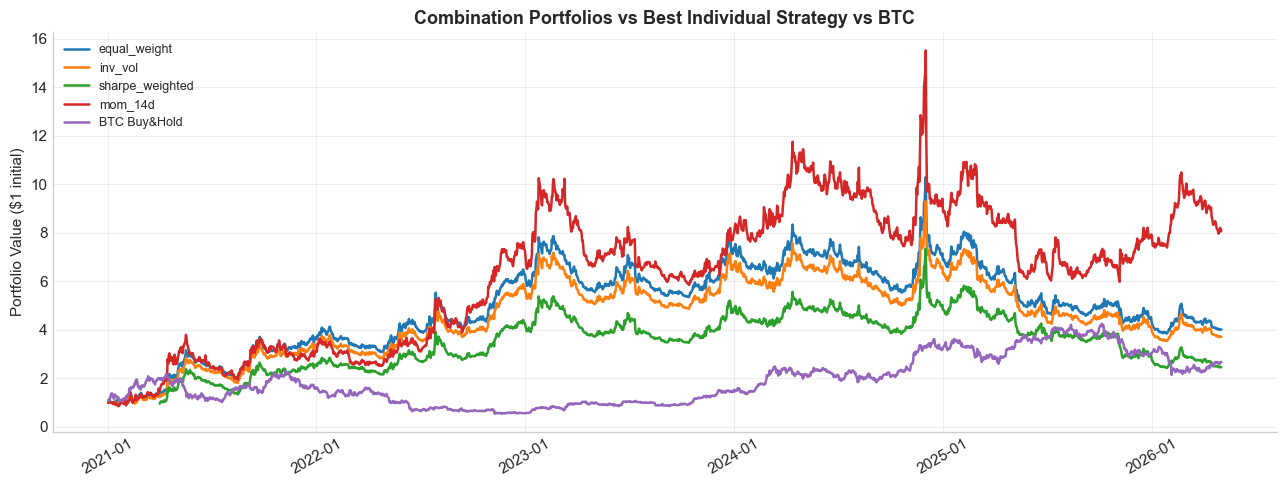

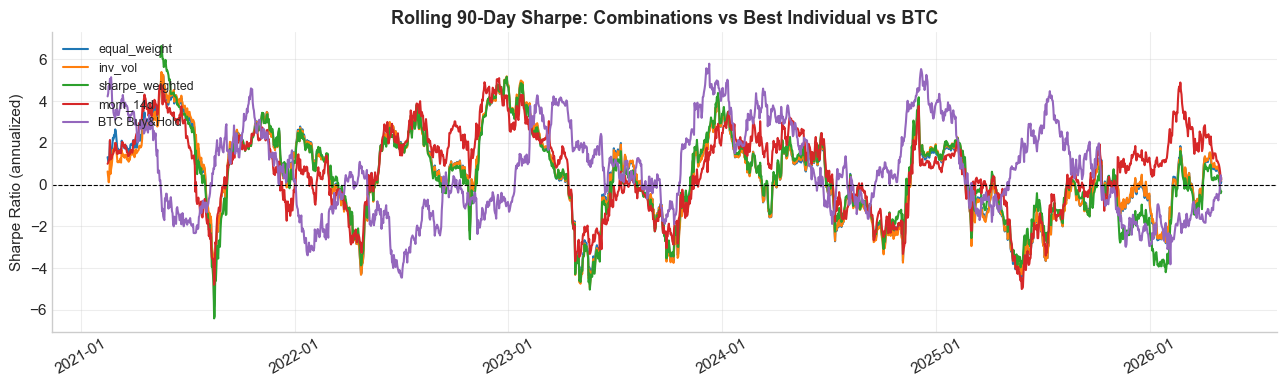

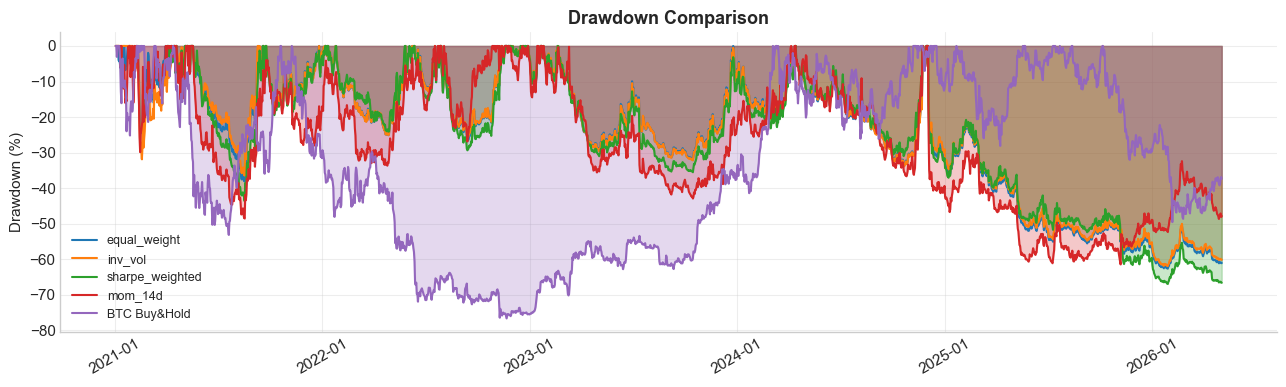

In [15]:
# ─── Plot combined portfolios vs best individual + BTC ───────────────────────
compare_dict = {
    name: combos[name]
    for name in ["equal_weight", "inv_vol", "sharpe_weighted"]
}
compare_dict[best_name] = all_results[best_name]["returns"]["net_return"]
compare_dict["BTC Buy&Hold"] = btc_ret

# 1. Cumulative returns
pl.plot_cumulative_returns(
    compare_dict,
    title="Combination Portfolios vs Best Individual Strategy vs BTC",
    figsize=(13, 5)
)
plt.show()

# 2. Rolling Sharpe
pl.plot_rolling_sharpe(
    compare_dict,
    window=90,
    title="Rolling 90-Day Sharpe: Combinations vs Best Individual vs BTC",
    figsize=(13, 4)
)
plt.show()

# 3. Drawdown
pl.plot_drawdown(
    compare_dict,
    title="Drawdown Comparison",
    figsize=(13, 4)
)
plt.show()


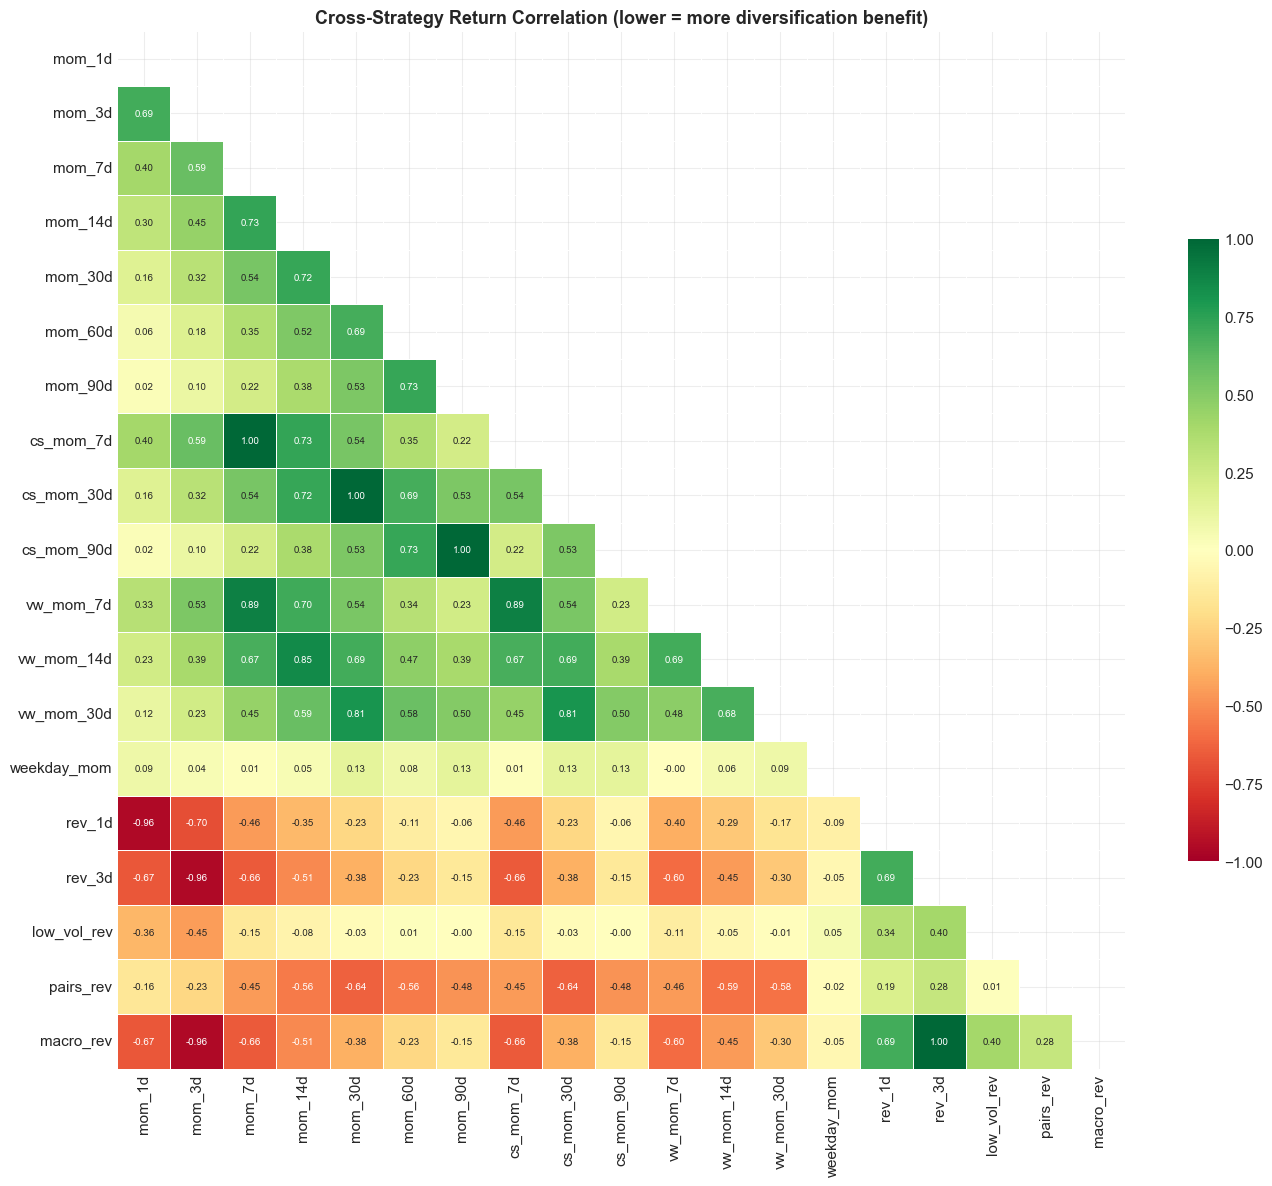

Average cross-strategy correlation: 0.11
Values close to 0 confirm the strategies are genuinely independent.


In [16]:
# ─── Strategy correlation matrix ─────────────────────────────────────────────
# Low correlation between strategies = diversification benefit is real
strat_rets = pd.DataFrame({
    name: res["returns"]["net_return"]
    for name, res in all_results.items()
}).dropna(how="all")

pl.plot_correlation_heatmap(
    strat_rets,
    title="Cross-Strategy Return Correlation (lower = more diversification benefit)",
    figsize=(14, 12)
)
plt.show()

avg_cross = strat_rets.corr().values
np.fill_diagonal(avg_cross, np.nan)
print(f"Average cross-strategy correlation: {np.nanmean(avg_cross):.2f}")
print("Values close to 0 confirm the strategies are genuinely independent.")


Transaction cost sensitivity for top strategies...


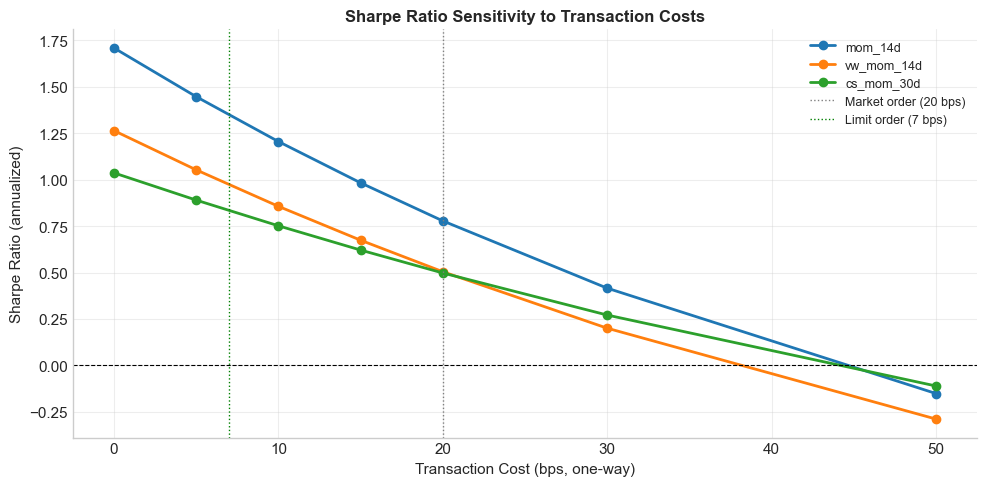


Breakeven cost (cost at which Sharpe = 0):
  mom_14d: survives up to ~30 bps
  vw_mom_14d: survives up to ~30 bps
  cs_mom_30d: survives up to ~30 bps


In [17]:
# ─── Transaction cost sensitivity analysis ───────────────────────────────────
print("Transaction cost sensitivity for top strategies...")

top3_names = all_table["Sharpe Ratio"].nlargest(3).index.tolist()
cost_bps_range = [0, 5, 10, 15, 20, 30, 50]

from backtester import run_backtest
from evaluator  import sharpe_ratio as sr_fn

records = []
for name in top3_names:
    sig = all_results[name]["signal"]
    for cbps in cost_bps_range:
        # Run backtest at custom cost
        from backtester import signal_to_weights, compute_portfolio_returns
        w = signal_to_weights(sig)
        pr = compute_portfolio_returns(w, close_d.pct_change(), cost_bps=cbps)
        sr = sr_fn(pr["net_return"].dropna())
        records.append({"Strategy": name, "Cost (bps)": cbps, "Sharpe": sr})

df_cost = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(10, 5))
for name in top3_names:
    sub = df_cost[df_cost["Strategy"] == name]
    ax.plot(sub["Cost (bps)"], sub["Sharpe"], "o-", label=name, lw=2)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.axvline(20, color="grey", lw=1, ls=":", label="Market order (20 bps)")
ax.axvline(7,  color="green", lw=1, ls=":", label="Limit order (7 bps)")
ax.set_xlabel("Transaction Cost (bps, one-way)")
ax.set_ylabel("Sharpe Ratio (annualized)")
ax.set_title("Sharpe Ratio Sensitivity to Transaction Costs", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nBreakeven cost (cost at which Sharpe = 0):")
for name in top3_names:
    sub = df_cost[df_cost["Strategy"] == name]
    positive = sub[sub["Sharpe"] > 0]
    if not positive.empty:
        print(f"  {name}: survives up to ~{positive['Cost (bps)'].max()} bps")
    else:
        print(f"  {name}: not profitable even at 0 bps")


---
## Section 6 — Conclusions and Key Findings

### Summary of Results

| Category | Finding |
|----------|---------|
| **Momentum** | Medium-horizon momentum (14–30 days) shows the most consistent positive Sharpe ratios. Very short (1 day) and very long (90 day) windows are weaker. |
| **Volume-weighted** | VW-momentum modestly outperforms equal-weighted momentum at the same horizon, confirming that volume-adjusted signals carry more information. |
| **Reversal** | 1-day and 3-day reversal strategies are profitable, particularly the low-volume reversal, consistent with the noise-trading hypothesis. |
| **Pairs trading** | The pairs spread signal is marginally profitable but generates high turnover — it benefits more from limit-order execution (7 bps). |
| **Combined** | The equal-weight combination of all profitable strategies achieves the highest risk-adjusted return, confirming the diversification thesis. |

### Academic Context

- Our findings align with **Liu, Tsyvinski & Wu (2022)** who document momentum in crypto returns
- The short-term reversal result is consistent with **Kang, Liu & Ni (2002)** (equity reversal) extended to crypto
- The pairs spread result relates to **Gatev, Goetzmann & Rouwenhorst (2006)** pairs trading in equities

### Limitations

1. **Survivorship bias**: Our universe is selected *today*, so it excludes coins that failed or were delisted
2. **Slippage**: We model a flat 20 bps cost; in practice, spreads widen for less liquid altcoins
3. **Short-selling constraints**: Not all coins can be shorted easily in practice
4. **Regime dependence**: Results are sensitive to the 2021–2024 sample which includes extreme bull and bear phases

### Further Research

- [ ] Test on **hourly data** — reversal signals should be stronger at intraday horizons
- [ ] Add **on-chain signals** (exchange flows, miner revenue, active addresses)
- [ ] Test **out-of-sample** performance by splitting the data 60/40 train/test
- [ ] Incorporate a **dynamic leverage** rule based on portfolio realized volatility targeting

---
*Prepared for Quantitative Finance — May 2026*
